# CORINE mapping and data preperation

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import numpy as np
import zipfile
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
from rasterio.enums import Resampling

user = os.environ.get("USER")
env_path = Path(f"/p/project1/training2600/{user}/envs/.env")

load_dotenv(dotenv_path=env_path, override=True)

True

## Processing Parameters

In [ ]:
user = "team1"

S2_DATA_DIR = f"/p/scratch/training2600/{user}/data/"

CORINE_PATH = "/p/scratch/training2600/CORINE/u2018_clc2018_v2020_20u1_raster100m/DATA/U2018_CLC2018_V2020_20u1.tif"

OUTPUT_DIR = f"/p/scratch/training2600/{user}/data/aligned_data"

TRAINING_DIR = f"/p/scratch/training2600/{user}/data/training_data"

RESULTS_DIR = f"/p/project1/training2600/{user}/results"

SKIP_EXISTING = True  # Skip tiles that already have output files

# --- Patch Extraction Parameters ---
PATCH_SIZE = 3       # Size in pixels (3 = 30m x 30m at 10m resolution)
STRIDE = None        # Stride for extraction (None = same as PATCH_SIZE, no overlap)
MAX_PATCHES = 50000  # Maximum patches per tile (increased to improve training quality)

COMBINE_CLASSES = True

# Options: 'minmax', 'zscore', 'percentile', 'none'
NORMALIZATION = 'percentile'
NORMALIZATIONS = ['minmax', 'zscore', 'percentile', 'none']

PERCENTILE_LOW = 2
PERCENTILE_HIGH = 98

%matplotlib inline

## CORINE mapping dics

In [3]:
# CORINE class descriptions (simplified codes 1-44 used in raster)
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    
    48: "No data"
}

# Color mapping for visualization
CORINE_COLORS = {
    1: '#E6004D', 2: '#FF0000', 3: '#CC4DF2', 4: '#CC0000', 5: '#E6CCCC',
    6: '#E6CCE6', 7: '#A600CC', 8: '#A64DCC', 9: '#FF4DFF', 10: '#FFA6FF',
    11: '#FFE6FF', 12: '#FFFFA8', 13: '#FFFF00', 14: '#E6E600', 15: '#E68000',
    16: '#F2A64D', 17: '#E6A600', 18: '#E6E64D', 19: '#FFE6A6', 20: '#FFE64D',
    21: '#E6CC4D', 22: '#F2CCA6', 23: "#90FF00", 24: '#00A600', 25: '#3DFF00',
    26: '#CCF24D', 27: '#A6FF80', 28: '#A6E64D', 29: '#A6F200', 30: '#E6E6E6',
    31: '#CCCCCC', 32: '#CCFFCC', 33: '#000000', 34: '#A6E6CC', 35: '#A6A6FF',
    36: '#4D4DFF', 37: '#CCCCFF', 38: '#E6E6FF', 39: '#A6A6E6', 40: '#00CCF2',
    41: '#80F2E6', 42: '#00FFA6', 43: '#A6FFE6', 44: '#E6F2FF'
}

In [4]:
CORINE_REDUCE_CLASSES = {
    # Artificial surfaces (1-11)
    1: 1, # "Continuous urban fabric"
    2: 2, # "Discontinuous urban fabric"
    3: 2, # "Industrial or commercial units"                                   #
    4: 4, # "Road and rail networks"
    5: 5, # "Port areas"
    6: 6, # "Airports"
    7: 7, # "Mineral extraction sites"
    8: 8, # "Dump sites"
    9: 9, # "Construction sites"
    10: 10, # "Green urban areas"
    11: 11, # "Sport and leisure facilities"
    
    # Agricultural areas (12-22)
    12: 12, # "Non-irrigated arable land"
    13: 13, # "Permanently irrigated land"
    14: 14, # "Rice fields"
    15: 15, # "Vineyards"
    16: 16, # "Fruit trees and berry plantations"
    17: 17, # "Olive groves"
    18: 21, # "Pastures"                                                       #
    19: 19, # "Annual crops with permanent crops"
    20: 21, # "Complex cultivation patterns"                                   #
    21: 21, # "Agriculture with natural vegetation"
    22: 22, # "Agro-forestry areas"
    
    # Forest and semi-natural areas (23-34)
    23: 25, # "Broad-leaved forest"                                            #
    24: 24, # "Coniferous forest"
    25: 25, # "Mixed forest"
    26: 26, # "Natural grasslands"
    27: 27, # "Moors and heathland"
    28: 28, # "Sclerophyllous vegetation"
    29: 29, # "Transitional woodland-shrub"
    30: 30, # "Beaches, dunes, sands"
    31: 31, # "Bare rocks"
    32: 32, # "Sparsely vegetated areas"
    33: 33, # "Burnt areas"
    34: 34, # "Glaciers and perpetual snow"
    
    # Wetlands (35-39)
    35: 36, # "Inland marshes"                                                 #
    36: 36, # "Peat bogs"
    37: 37, # "Salt marshes"
    38: 38, # "Salines"
    39: 39, # "Intertidal flats"
    
    # Water bodies (40-44)
    40: 41, # "Water courses"                                                  #
    41: 41, # "Water bodies"
    42: 42, # "Coastal lagoons"
    43: 43, # "Estuaries"
    44: 44, # "Sea and ocean"
    
    48: 48, # "No data
}

## Function definitions

### Copied from 2.1

In [18]:
def find_s2_tiles(data_dir):
    """
    Find Sentinel-2 .SAFE directories to process.
    
    Parameters:
    -----------
    data_dir : str
        Directory containing .SAFE folders
    selection : str
        'all' to find all tiles, 'list' to use tile_list
    tile_list : list
        List of specific tile names to process
    
    Returns:
    --------
    list : List of Path objects for .SAFE directories
    """
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"❌ Data directory not found: {data_dir}")
        return []
    
    zip_files = list(data_path.glob("*.zip"))
    if zip_files:
        print(f"⚠ Found ZIP files in {data_dir}. Extracting them first...")
        for zip_file in zip_files:
            extract_sentinel2(zip_file, data_dir)
    tiles = sorted(data_path.glob("*.SAFE"))

    return tiles

def extract_sentinel2(zip_path, output_dir=None):
    """
    Extract a Sentinel-2 ZIP file to a SAFE directory.
    
    Parameters:
    -----------
    zip_path : str
        Path to the Sentinel-2 ZIP file
    output_dir : str, optional
        Directory to extract to. If None, extracts to same directory as ZIP.
    
    Returns:
    --------
    str : Path to extracted SAFE directory
    """    
    if output_dir is None:
        output_dir = os.path.dirname(zip_path)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Get the SAFE directory name (first item in the archive)
        safe_dir = zip_ref.namelist()[0].split('/')[0]
        safe_path = os.path.join(output_dir, safe_dir)
        
        if os.path.exists(safe_path):
            print(f"  ⚠ Already extracted: {safe_dir}")
        else:
            zip_ref.extractall(output_dir)
            print(f"  ✓ Extracted to: {safe_path}")
    
    return safe_path

def stack_s2_bands(safe_path, output_path):
    """
    Stack Sentinel-2 bands (B02, B03, B04, B08) into a single GeoTIFF.
    
    Parameters:
    -----------
    safe_path : Path
        Path to .SAFE directory
    output_path : Path
        Output path for stacked GeoTIFF
    
    Returns:
    --------
    dict : Info about the stacked file (crs, bounds, etc.) or None on failure
    """
    bands = ['B02', 'B03', 'B04', 'B08']  # Blue, Green, Red, NIR
    resolution = '10m'
    
    try:
        # Find band files
        band_paths = {}
        for band_name in bands:
            pattern = f"**/R{resolution}/*_{band_name}_{resolution}.jp2"
            matches = list(safe_path.glob(pattern))
            if matches:
                band_paths[band_name] = matches[0]
            else:
                print(f"  ⚠ {band_name} not found")
                return None
        
        # Read first band for metadata
        with rasterio.open(band_paths['B02']) as src:
            profile = src.profile.copy()
            height, width = src.height, src.width
            crs = src.crs
            transform = src.transform
            bounds = src.bounds
        
        # Update profile for output
        profile.update(
            driver='GTiff',
            count=len(bands),
            dtype='uint16',
            compress='lzw',
            tiled=True,
            blockxsize=256,
            blockysize=256
        )
        
        # Create output and write bands
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i, (band_name, band_path) in enumerate(band_paths.items(), start=1):
                with rasterio.open(band_path) as src:
                    data = src.read(1)
                    dst.write(data, i)
                    dst.set_band_description(i, band_name)
        
        return {
            'crs': crs,
            'width': width,
            'height': height,
            'transform': transform,
            'bounds': bounds,
            'bands': bands
        }
        
    except Exception as e:
        print(f"  ❌ Band stacking failed: {e}")
        import traceback
        traceback.print_exc()
        return None

def align_corine_to_s2(corine_path, s2_path, output_path):
    """
    Align CORINE raster to match Sentinel-2 tile geometry using rasterio.
    
    Parameters:
    -----------
    corine_path : Path
        Path to CORINE GeoTIFF
    s2_path : Path
        Path to stacked S2 GeoTIFF (reference)
    output_path : Path
        Output path for aligned CORINE
    
    Returns:
    --------
    bool : Success status
    """
    try:
        # Get S2 geometry (target)
        with rasterio.open(s2_path) as s2_src:
            dst_crs = s2_src.crs
            dst_transform = s2_src.transform
            dst_width = s2_src.width
            dst_height = s2_src.height
            dst_bounds = s2_src.bounds
        
        print(f"    Target CRS: {dst_crs}")
        print(f"    Target size: {dst_width} x {dst_height} pixels")
        print(f"    Target bounds: {dst_bounds}")
        
        # Open CORINE and reproject
        with rasterio.open(corine_path) as src:
            # Create output profile
            out_profile = src.profile.copy()
            out_profile.update(
                driver='GTiff',
                crs=dst_crs,
                transform=dst_transform,
                width=dst_width,
                height=dst_height,
                compress='lzw',
                tiled=True
            )
            
            # Create output raster
            with rasterio.open(output_path, 'w', **out_profile) as dst:
                # Reproject using nearest neighbor (for categorical data)
                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )
        
        return True
        
    except Exception as e:
        print(f"  ❌ CORINE alignment failed: {e}")
        import traceback
        traceback.print_exc()
        return False


def check_corine_coverage(corine_path):
    """
    Check if aligned CORINE has valid data.
    
    Returns:
    --------
    tuple : (has_valid_data, unique_classes, coverage_percent)
    """
    with rasterio.open(corine_path) as src:
        data = src.read(1)
    
    total_pixels = data.size
    valid_mask = (data >= 1) & (data <= 44)
    valid_pixels = np.sum(valid_mask)
    coverage_percent = (valid_pixels / total_pixels) * 100
    
    unique = np.unique(data[valid_mask])
    
    return len(unique) > 0, unique, coverage_percent

def process_tile_alignment(safe_path, corine_path, output_dir, skip_existing=True):
    """
    Process a single Sentinel-2 tile: stack bands and align CORINE.
    
    Returns:
    --------
    dict : Processing results
    """
    tile_name = safe_path.stem
    result = {
        'tile': tile_name,
        'status': 'unknown',
        's2_stacked': None,
        'corine_aligned': None,
        'crs': None,
        'n_classes': 0,
        'coverage_percent': 0
    }
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Output paths
    s2_stacked = output_dir / f"{tile_name}_stacked.tif"
    corine_aligned = output_dir / f"corine_aligned_{tile_name}.tif"
    
    # Check for existing output
    if skip_existing and s2_stacked.exists() and corine_aligned.exists():
        print(f"  ⏭ Skipping (outputs exist)")
        has_coverage, classes, coverage = check_corine_coverage(corine_aligned)
        result['status'] = 'skipped'
        result['s2_stacked'] = str(s2_stacked)
        result['corine_aligned'] = str(corine_aligned)
        result['n_classes'] = len(classes)
        result['coverage_percent'] = coverage
        return result
    
    # Step 1: Stack bands
    print(f"  📦 Stacking S2 bands...")
    stack_info = stack_s2_bands(safe_path, s2_stacked)
    if stack_info is None:
        result['status'] = 'failed_stacking'
        return result
    
    result['crs'] = str(stack_info['crs'])
    print(f"    Created: {s2_stacked.name}")
    print(f"    Size: {stack_info['width']} x {stack_info['height']} pixels")
    print(f"    CRS: {stack_info['crs']}")
    
    # Step 2: Align CORINE
    print(f"  🗺️ Aligning CORINE to S2 geometry...")
    if not align_corine_to_s2(corine_path, s2_stacked, corine_aligned):
        result['status'] = 'failed_alignment'
        return result
    
    # Step 3: Check coverage
    print(f"  🔍 Checking CORINE coverage...")
    has_coverage, classes, coverage = check_corine_coverage(corine_aligned)
    
    if not has_coverage:
        print(f"  ⚠ No valid CORINE data (tile outside coverage?)")
        result['status'] = 'no_coverage'
        return result
    
    result['status'] = 'success'
    result['s2_stacked'] = str(s2_stacked)
    result['corine_aligned'] = str(corine_aligned)
    result['n_classes'] = len(classes)
    result['coverage_percent'] = coverage
    
    print(f"    CORINE classes found: {len(classes)}")
    print(f"    Valid coverage: {coverage:.1f}%")
    
    return result

def visualize_alignment(s2_path, corine_path, title="Alignment Verification", save_path=None, is_show_plot=True):
    """
    Visualize the S2 image and aligned CORINE side by side.
    
    Parameters:
    -----------
    s2_path : str or Path
        Path to stacked S2 GeoTIFF
    corine_path : str or Path
        Path to aligned CORINE GeoTIFF
    title : str
        Plot title
    save_path : str or Path, optional
        Path to save the figure (PNG format)
    """
    # Load S2 data
    with rasterio.open(s2_path) as src:
        # Read RGB bands (B04, B03, B02 = bands 3, 2, 1)
        r = src.read(3).astype(float)  # B04 (Red)
        g = src.read(2).astype(float)  # B03 (Green)
        b = src.read(1).astype(float)  # B02 (Blue)
    
    # Create RGB composite
    rgb = np.stack([r, g, b], axis=-1)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
    
    # Load CORINE data
    with rasterio.open(corine_path) as src:
        corine = src.read(1)
    
    # Create CORINE colormap
    from matplotlib.colors import ListedColormap
    unique_classes = np.unique(corine[(corine >= 1) & (corine <= 44)])
    colors = [CORINE_COLORS.get(c, '#888888') for c in range(45)]
    cmap = ListedColormap(colors)
    
    # Create figure (subsample for display)
    step = 10
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # S2 RGB
    axes[0].imshow(rgb[::step, ::step])
    axes[0].set_title('Sentinel-2 RGB (B04, B03, B02)', fontsize=12)
    axes[0].axis('off')
    
    # CORINE
    axes[1].imshow(corine[::step, ::step], cmap=cmap, vmin=0, vmax=44)
    axes[1].set_title('Aligned CORINE Land Cover', fontsize=12)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(rgb[::step, ::step])
    corine_masked = np.ma.masked_where((corine < 1) | (corine > 44), corine)
    axes[2].imshow(corine_masked[::step, ::step], cmap=cmap, vmin=0, vmax=44, alpha=0.4)
    axes[2].set_title('S2 + CORINE Overlay', fontsize=12)
    axes[2].axis('off')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = []
    for c in sorted(unique_classes):
        color = CORINE_COLORS.get(c, '#888888')
        label = f"{c}: {CORINE_CLASSES.get(c, 'Unknown')}"
        legend_elements.append(Patch(facecolor=color, edgecolor='black', label=label))
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=5,
        fontsize=7,
        title="CORINE Classes",
    )
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"✓ Figure saved to: {save_path}")
    
    if is_show_plot:
        plt.show()
    
    # Print class distribution
    print("\nCORINE Classes in this tile:")
    for c in sorted(unique_classes):
        count = np.sum(corine == c)
        pct = count / corine.size * 100
        print(f"  Class {c:2d}: {CORINE_CLASSES.get(c, 'Unknown')[:30]:30s} - {count:,} pixels ({pct:.1f}%)")

### Normalization function

In [19]:
def normalize_minmax(data, min_val=0, max_val=10000, **kwargs):
    """
    Min-max normalization to [0, 1] range.
    
    Parameters:
    -----------
    data : np.ndarray
        Input data (any shape)
    min_val : float
        Minimum value for scaling (default 0 for S2)
    max_val : float
        Maximum value for scaling (default 10000 for S2 L2A)
    
    Returns:
    --------
    np.ndarray : Normalized data in [0, 1]
    """
    data = data.astype(np.float32)
    normalized = (data - min_val) / (max_val - min_val + 1e-6)
    return np.clip(normalized, 0, 1)


def normalize_zscore(data, mean=None, std=None, **kwargs):
    """
    Z-score normalization (standardization).
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    mean : float or None
        Mean value (computed if None)
    std : float or None
        Std value (computed if None)
    
    Returns:
    --------
    tuple : (normalized_data, mean, std)
    """
    data = data.astype(np.float32)
    if mean is None:
        mean = np.mean(data)
    if std is None:
        std = np.std(data)
    normalized = (data - mean) / (std + 1e-6)
    return normalized, mean, std


def normalize_percentile(data, low_pct=2, high_pct=98, **kwargs):
    """
    Percentile-based normalization (robust to outliers).
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    low_pct : float
        Low percentile for clipping
    high_pct : float
        High percentile for clipping
    
    Returns:
    --------
    tuple : (normalized_data, low_val, high_val)
    """
    data = data.astype(np.float32)
    low_val = np.percentile(data, low_pct)
    high_val = np.percentile(data, high_pct)
    normalized = (data - low_val) / (high_val - low_val + 1e-6)
    normalized = np.clip(normalized, 0, 1)
    return normalized, low_val, high_val


def normalize_data(data, method='percentile', **kwargs):
    """
    Normalize data using specified method.
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    method : str
        'minmax', 'zscore', 'percentile', or 'none'
    **kwargs : dict
        Additional arguments for the normalization method
    
    Returns:
    --------
    tuple : (normalized_data, norm_params)
    """
    if method == 'minmax':
        normalized = normalize_minmax(data, **kwargs)
        params = {'method': 'minmax', **kwargs}
    elif method == 'zscore':
        normalized, mean, std = normalize_zscore(data, **kwargs)
        params = {'method': 'zscore', 'mean': float(mean), 'std': float(std)}
    elif method == 'percentile':
        low_pct = kwargs.get('low_pct', 2)
        high_pct = kwargs.get('high_pct', 98)
        normalized, low_val, high_val = normalize_percentile(data, low_pct, high_pct)
        params = {'method': 'percentile', 'low_pct': low_pct, 'high_pct': high_pct,
                  'low_val': float(low_val), 'high_val': float(high_val)}
    else:  # 'none'
        normalized = data.astype(np.float32)
        params = {'method': 'none'}
    
    return normalized, params

### Copied from 2.2

In [20]:
def find_aligned_pairs(data_dir):
    """
    Find pairs of stacked S2 and aligned CORINE files.
    
    Returns:
    --------
    list : List of dicts with 's2_path', 'corine_path', 'tile_name'
    """
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"❌ Data directory not found: {data_dir}")
        return []
    
    s2_files = sorted(data_path.glob("*_stacked.tif"))
    
    pairs = []
    for s2_path in s2_files:
        tile_name = s2_path.stem.replace('_stacked', '')
        corine_path = data_path / f"corine_aligned_{tile_name}.tif"
        
        if corine_path.exists():
            pairs.append({
                's2_path': s2_path,
                'corine_path': corine_path,
                'tile_name': tile_name
            })
        else:
            print(f"⚠ Missing CORINE for: {tile_name}")
    
    return pairs

def extract_patches(s2_path, corine_path, patch_size=3, stride=None, max_patches=50000,
                    normalization='percentile', norm_kwargs=None):
    """
    Extract training patches from aligned S2 imagery with CORINE labels.
    
    Parameters:
    -----------
    s2_path : Path
        Path to stacked S2 GeoTIFF
    corine_path : Path
        Path to aligned CORINE GeoTIFF
    patch_size : int
        Patch size in pixels
    stride : int
        Stride for extraction (None = patch_size)
    max_patches : int
        Maximum patches to extract
    normalization : str
        Normalization method
    norm_kwargs : dict
        Additional arguments for normalization
    
    Returns:
    --------
    tuple : (patches, labels, metadata) or (None, None, None)
    """
    if norm_kwargs is None:
        norm_kwargs = {}
    
    try:
        # Open datasets using rasterio
        with rasterio.open(s2_path) as s2_src, rasterio.open(corine_path) as corine_src:
            n_bands = s2_src.count
            height = s2_src.height
            width = s2_src.width
            
            if stride is None:
                stride = patch_size
            
            print(f"    Image size: {width} x {height} pixels")
            print(f"    Bands: {n_bands}")
            print(f"    Patch size: {patch_size}, Stride: {stride}")
            
            # Read all data into memory (for efficiency)
            # Shape: (bands, height, width)
            s2_data = s2_src.read()
            corine_data = corine_src.read(1)
        
        # Apply normalization to entire image first (for consistent statistics)
        print(f"    Applying {normalization} normalization...")
        s2_normalized, norm_params = normalize_data(s2_data, normalization, **norm_kwargs)

        # Reverse Images
        s2_normalized = s2_normalized[:, ::-1, ::-1]
        corine_data = corine_data[::-1, ::-1]

        # Extract patches
        patches, labels = [], []
        
        for y in range(0, height - patch_size + 1, stride):
            for x in range(0, width - patch_size + 1, stride):
                # Extract patch (bands, h, w) -> (h, w, bands)
                patch = s2_normalized[:, y:y+patch_size, x:x+patch_size]
                patch = np.transpose(patch, (1, 2, 0))  # (H, W, C)
                
                # Get center pixel label
                center_y = y + patch_size // 2
                center_x = x + patch_size // 2
                label = corine_data[center_y, center_x]
                if COMBINE_CLASSES:
                    label = CORINE_REDUCE_CLASSES[label]
                
                # Skip invalid labels (must be 1-44)
                if label < 1 or label > 44:
                    # print(f"    ⚠ Skipping patch at ({x}, {y}) - invalid label: {label}")
                    continue
                
                # Skip patches with missing S2 data (check original before normalization)
                original_patch = s2_data[:, y:y+patch_size, x:x+patch_size]
                if np.any(original_patch == 0):
                    # print(f"    ⚠ Skipping patch at ({x}, {y}) - missing S2 data")
                    continue
                
                patches.append(patch)
                labels.append(label)
                
                if len(patches) >= max_patches:
                    print(f"    Reached maximum patch limit: {max_patches}")
                    break
            
            if len(patches) >= max_patches:
                break
            
            # Progress update
            if y % 2000 == 0 and y > 0:
                print(f"    Progress: {len(patches):,} patches extracted...")
        
        if len(patches) == 0:
            return None, None, None
        
        # Convert to arrays
        patches = np.array(patches, dtype=np.float32)
        labels = np.array(labels, dtype=np.uint8)
        
        # Create metadata
        unique_labels, counts = np.unique(labels, return_counts=True)
        metadata = {
            's2_file': Path(s2_path).name,
            'corine_file': Path(corine_path).name,
            'patch_size': patch_size,
            'stride': stride,
            'n_patches': len(patches),
            'n_bands': patches.shape[3],
            'n_classes': len(unique_labels),
            'label_distribution': {int(k): int(v) for k, v in zip(unique_labels, counts)},
            'extraction_date': datetime.now().isoformat(),
            'patch_shape': list(patches.shape),
            'bands': ['B02', 'B03', 'B04', 'B08'],
            'normalization': norm_params
        }
        
        return patches, labels, metadata
        
    except Exception as e:
        print(f"  ❌ Patch extraction failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

def process_tile_extraction(pair, output_dir, patch_size, stride, max_patches,
                            normalization, norm_kwargs, skip_existing=True):
    """
    Extract patches from a single aligned tile pair.
    
    Returns:
    --------
    dict : Processing results
    """
    tile_name = pair['tile_name']
    s2_path = pair['s2_path']
    corine_path = pair['corine_path']
    
    result = {
        'tile': tile_name,
        'status': 'unknown',
        'n_patches': 0,
        'n_classes': 0,
        'output_file': None,
        'metadata': None
    }

    output_dir = Path(output_dir)
    output_dir = output_dir / f"normalization_{normalization}"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Output paths
    output_npz = output_dir / f"patches_{tile_name}_data.npz"
    metadata_file = output_dir / f"patches_{tile_name}_metadata.json"
    
    # Check for existing output
    if skip_existing and output_npz.exists():
        print(f"  ⏭ Skipping (output exists)")
        if metadata_file.exists():
            with open(metadata_file) as f:
                result['metadata'] = json.load(f)
                result['n_patches'] = result['metadata'].get('n_patches', 0)
                result['n_classes'] = result['metadata'].get('n_classes', 0)
        result['status'] = 'skipped'
        result['output_file'] = str(output_npz)
        return result
    
    # Extract patches
    print(f"  ✂️ Extracting patches...")
    patches, labels, metadata = extract_patches(
        s2_path, corine_path, 
        patch_size=patch_size, 
        stride=stride, 
        max_patches=max_patches,
        normalization=normalization,
        norm_kwargs=norm_kwargs
    )
    
    if patches is None:
        result['status'] = 'no_patches'
        return result
    
    # Save results
    print(f"  💾 Saving {len(patches):,} patches...")
    np.savez_compressed(output_npz, patches=patches, labels=labels)
    
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    result['status'] = 'success'
    result['n_patches'] = len(patches)
    result['n_classes'] = metadata['n_classes']
    result['output_file'] = str(output_npz)
    result['metadata'] = metadata
    
    return result

def combine_datasets(result_list, output_path):
    """
    Combine patches from multiple tiles into a single dataset.
    """
    all_patches = []
    all_labels = []
    
    for result in result_list:
        if result['status'] not in ['success', 'skipped']:
            continue
        if not result['output_file'] or not Path(result['output_file']).exists():
            continue
        
        data = np.load(result['output_file'])
        patches = data['patches']
        labels = data['labels']
        
        all_patches.append(patches)
        all_labels.append(labels)
        
        print(f"  Added {len(labels):,} patches from {result['tile'][:40]}...")
    
    if not all_patches:
        print("No data to combine!")
        return None, None
    
    # Concatenate
    combined_patches = np.concatenate(all_patches, axis=0)
    combined_labels = np.concatenate(all_labels, axis=0)
    
    # Shuffle
    indices = np.random.permutation(len(combined_labels))
    combined_patches = combined_patches[indices]
    combined_labels = combined_labels[indices]
    
    # Save
    np.savez_compressed(output_path, patches=combined_patches, labels=combined_labels)
    
    print(f"\n✓ Combined dataset saved: {output_path}")
    print(f"  Total patches: {len(combined_labels):,}")
    print(f"  Unique classes: {len(np.unique(combined_labels))}")
    print(f"  File size: {Path(output_path).stat().st_size / (1024**2):.1f} MB")
    
    return combined_patches, combined_labels

def concatenate_metadata(metadata_files, output_path):
    """
    Combine multiple metadata JSON files into one file by storing each tile's
    metadata separately.

    Parameters
    ----------
    metadata_files : list of Path or str
        Paths to *_metadata.json files
    output_path : Path or str
        Output path for combined metadata JSON
    """
    tiles = []

    for path in metadata_files:
        path = Path(path)
        if not path.exists():
            print(f"Warning: Metadata file not found: {path}")
            continue

        with open(path, "r") as f:
            meta = json.load(f)
        
        meta["metadata_file"] = path.name
        meta["data_file"] = path.with_name(
            path.stem.removesuffix("_metadata") + "_data.npz"
        ).name
        
        tiles.append(meta)

    if not tiles:
        print("No metadata files found!")
        return None

    # Summary fields for all four tiles combined
    total_patches = sum(tile.get("n_patches", 0) for tile in tiles)

    combined_metadata = {
        "dataset_type": "combined_tiles",
        "n_tiles": len(tiles),
        "total_patches": total_patches,
        "combined_date": datetime.now().isoformat(),
        "tiles": tiles
    }

    output_path = Path(output_path)
    with open(output_path, "w") as f:
        json.dump(combined_metadata, f, indent=2)

    print(f"✓ Concatenated metadata saved: {output_path}")
    print(f"  Number of tiles: {len(tiles)}")
    print(f"  Total patches: {total_patches:,}")

    return combined_metadata



### Copied from 2.2 visualization

In [21]:
def visualize_patches(patches, labels, n_samples=12, title="Sample Patches", is_show_plot=True):
    """
    Visualize sample patches with their labels.
    """
    # Get diverse samples (one or two per class)
    unique_labels = np.unique(labels)
    
    sample_indices = []
    for label in unique_labels:
        indices = np.where(labels == label)[0]
        n_from_class = min(2, len(indices))
        sample_indices.extend(np.random.choice(indices, n_from_class, replace=False))
        if len(sample_indices) >= n_samples:
            break
    
    sample_indices = sample_indices[:n_samples]
    
    # Create figure
    n_cols = 4
    n_rows = (len(sample_indices) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
    
    for i, idx in enumerate(sample_indices):
        patch = patches[idx]
        label = labels[idx]
        
        # Create RGB composite (already normalized, just use R, G, B)
        # Bands are B02, B03, B04, B08 -> RGB is B04, B03, B02 = indices 2, 1, 0
        rgb = patch[:, :, [2, 1, 0]]
        rgb = np.clip(rgb, 0, 1)  # Ensure in [0, 1]
        
        # Upscale for visibility
        rgb_upscaled = np.repeat(np.repeat(rgb, 20, axis=0), 20, axis=1)
        
        axes[i].imshow(rgb_upscaled)
        class_name = CORINE_CLASSES.get(label, "Unknown")[:25]
        axes[i].set_title(f"Class {label}: {class_name}", fontsize=10)
        axes[i].axis('off')
    
    # Hide unused axes
    for i in range(len(sample_indices), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    output_dir = Path(RESULTS_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / "patches_viz.png")

    if is_show_plot:
        plt.show()

def plot_class_distribution(labels, title="Class Distribution"):
    """
    Plot the distribution of CORINE classes.
    """
    unique, counts = np.unique(labels, return_counts=True)
    
    # Sort by count
    sort_idx = np.argsort(counts)[::-1]
    unique = unique[sort_idx]
    counts = counts[sort_idx]
    
    # Get class names and colors
    class_names = [f"{c}: {CORINE_CLASSES.get(c, 'Unknown')[:20]}" for c in unique]
    colors = [CORINE_COLORS.get(c, '#888888') for c in unique]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart
    bars = ax1.barh(range(len(unique)), counts, color=colors)
    ax1.set_yticks(range(len(unique)))
    ax1.set_yticklabels(class_names, fontsize=9)
    ax1.set_xlabel('Number of Patches')
    ax1.set_title('Patch Count by Class')
    ax1.invert_yaxis()
    
    # Add count labels
    for i, (count, bar) in enumerate(zip(counts, bars)):
        ax1.text(count + max(counts)*0.01, i, f'{count:,}', va='center', fontsize=8)
    
    # Pie chart (top 10)
    top_n = min(10, len(unique))
    other_count = counts[top_n:].sum() if len(counts) > top_n else 0
    
    pie_counts = list(counts[:top_n])
    pie_labels = [f"{c}" for c in unique[:top_n]]
    pie_colors = colors[:top_n]
    
    if other_count > 0:
        pie_counts.append(other_count)
        pie_labels.append('Other')
        pie_colors.append('#888888')
    
    ax2.pie(pie_counts, labels=pie_labels, colors=pie_colors, 
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('Top 10 Classes Distribution')

    output_dir = Path(RESULTS_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / "class_distribution.png")
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics:")
    print(f"  Total patches: {len(labels):,}")
    print(f"  Unique classes: {len(unique)}")
    print(f"  Most common: Class {unique[0]} ({CORINE_CLASSES.get(unique[0], 'Unknown')}) - {counts[0]:,} ({counts[0]/len(labels)*100:.1f}%)")
    print(f"  Least common: Class {unique[-1]} ({CORINE_CLASSES.get(unique[-1], 'Unknown')}) - {counts[-1]:,} ({counts[-1]/len(labels)*100:.1f}%)")
    
    # Class imbalance ratio
    imbalance_ratio = counts[0] / counts[-1]
    print(f"  Class imbalance ratio: {imbalance_ratio:.1f}:1")

## Find tiles and check CORINE file

In [26]:
available_tiles = find_s2_tiles(S2_DATA_DIR)
print(f"✅ Found {len(available_tiles)} tiles to process.")
for tile in available_tiles:
    print(f"  - {tile.name}")

print()

corine_path = Path(CORINE_PATH)
if not corine_path.exists():
    print(f"❌ CORINE file not found: {CORINE_PATH}")
    print("\nPlease check the path or download CORINE data.")
else:
    with rasterio.open(corine_path) as src:
        print("✓ CORINE Land Cover 2018")
        print(f"  File: {corine_path.name}")

⚠ Found ZIP files in /p/scratch/training2600/team1/data/. Extracting them first...
  ⚠ Already extracted: S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230723T023511.SAFE
  ⚠ Already extracted: S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912.SAFE
  ⚠ Already extracted: S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_20230709T051146.SAFE
  ⚠ Already extracted: S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_20230903T071056.SAFE
✅ Found 4 tiles to process.
  - S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912.SAFE
  - S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230723T023511.SAFE
  - S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_20230903T071056.SAFE
  - S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_20230709T051146.SAFE

✓ CORINE Land Cover 2018
  File: U2018_CLC2018_V2020_20u1.tif


## Process each tile

In [27]:
print(f"Tiles to process: {len(available_tiles)}")
print(f"Output directory: {OUTPUT_DIR}")
print()

all_results = []

# Process each tile
for i, tile_path in enumerate(available_tiles, 1):
    print(f"\n[{i}/{len(available_tiles)}] Processing: {tile_path.name}")
    
    result = process_tile_alignment(
        safe_path=tile_path,
        corine_path=CORINE_PATH,
        output_dir=OUTPUT_DIR,
        skip_existing=SKIP_EXISTING
    )
    
    all_results.append(result)
    
    if result['status'] == 'success':
        print(f"  ✅ Success: {result['n_classes']} classes, {result['coverage_percent']:.1f}% coverage")
    elif result['status'] == 'skipped':
        print(f"  ⏭ Skipped (already processed)")
    else:
        print(f"  ❌ Status: {result['status']}")

Tiles to process: 4
Output directory: /p/scratch/training2600/team1/data/aligned_data


[1/4] Processing: S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)

[2/4] Processing: S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230723T023511.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)

[3/4] Processing: S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_20230903T071056.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)

[4/4] Processing: S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_20230709T051146.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)


## Visualize results

Visualizing: S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230...
✓ Figure saved to: /p/project1/training2600/team1/results/alignment_S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230.png


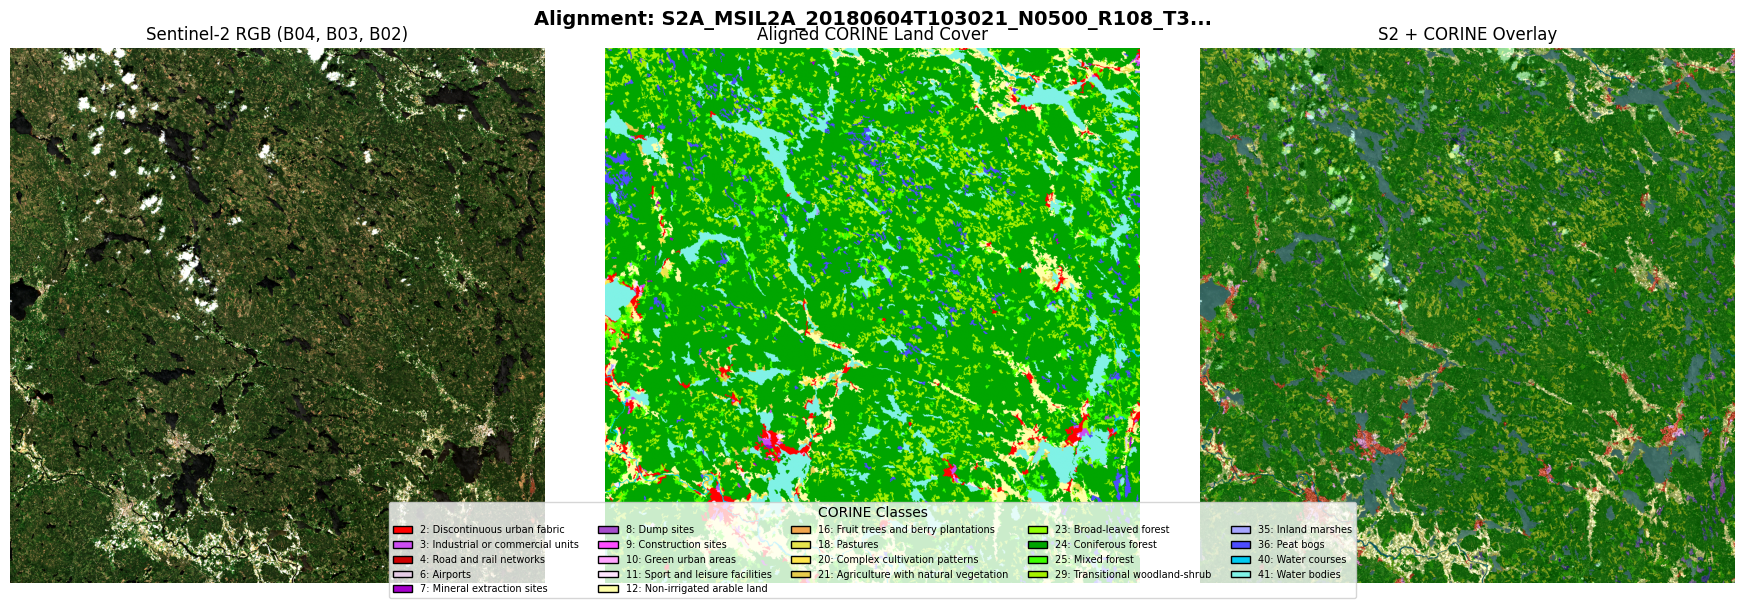


CORINE Classes in this tile:
  Class  2: Discontinuous urban fabric     - 1,783,363 pixels (1.5%)
  Class  3: Industrial or commercial units - 221,051 pixels (0.2%)
  Class  4: Road and rail networks         - 6,491 pixels (0.0%)
  Class  6: Airports                       - 34,575 pixels (0.0%)
  Class  7: Mineral extraction sites       - 54,661 pixels (0.0%)
  Class  8: Dump sites                     - 19,387 pixels (0.0%)
  Class  9: Construction sites             - 3,295 pixels (0.0%)
  Class 10: Green urban areas              - 49,814 pixels (0.0%)
  Class 11: Sport and leisure facilities   - 127,916 pixels (0.1%)
  Class 12: Non-irrigated arable land      - 7,197,020 pixels (6.0%)
  Class 16: Fruit trees and berry plantati - 3,002 pixels (0.0%)
  Class 18: Pastures                       - 180,700 pixels (0.1%)
  Class 20: Complex cultivation patterns   - 383,570 pixels (0.3%)
  Class 21: Agriculture with natural veget - 779,416 pixels (0.6%)
  Class 23: Broad-leaved forest       

In [14]:
# Visualize first (or other) successful result
successful_results = [r for r in all_results if r['status'] in ['success', 'skipped']]

if successful_results:
    result = successful_results[1] # Change to change which result is visualized
    tile_name = result['tile']
    
    # Create save path for the visualization
    save_path = Path(RESULTS_DIR) / f"alignment_{tile_name[:50]}.png"
    
    print(f"Visualizing: {tile_name[:50]}...")
    visualize_alignment(
        result['s2_stacked'], 
        result['corine_aligned'],
        title=f"Alignment: {tile_name[:40]}...",
        save_path=save_path
    )
else:
    print("No successful results to visualize.")

In [15]:
# Display detailed results
print("Detailed Results per Tile:")
print("-" * 90)
print(f"{'Tile':<50} {'Status':<15} {'Classes':<10} {'Coverage':<10}")
print("-" * 90)

for result in all_results:
    tile_short = result['tile'][:48] + ".." if len(result['tile']) > 50 else result['tile']
    coverage = f"{result['coverage_percent']:.1f}%" if result['coverage_percent'] > 0 else "-"
    classes = str(result['n_classes']) if result['n_classes'] > 0 else "-"
    print(f"{tile_short:<50} {result['status']:<15} {classes:<10} {coverage:<10}")

Detailed Results per Tile:
------------------------------------------------------------------------------------------
Tile                                               Status          Classes    Coverage  
------------------------------------------------------------------------------------------
S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_202.. skipped         22         100.0%    
S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_202.. skipped         22         100.0%    
S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_202.. skipped         22         100.0%    
S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_202.. skipped         22         100.0%    


## Extract patches

In [22]:
aligned_pairs = find_aligned_pairs(OUTPUT_DIR)

norm_kwargs = {}
if NORMALIZATION == 'percentile':
    norm_kwargs = {'low_pct': PERCENTILE_LOW, 'high_pct': PERCENTILE_HIGH}

# Store results
all_results = []

# Process each tile
for i, pair in enumerate(aligned_pairs, 1):
    print(f"\n[{i}/{len(aligned_pairs)}] Processing: {pair['tile_name'][:50]}...")

    for normalization in NORMALIZATIONS:
        result = process_tile_extraction(
            pair=pair,
            output_dir=TRAINING_DIR,
            patch_size=PATCH_SIZE,
            stride=STRIDE,
            max_patches=MAX_PATCHES,
            normalization=normalization,
            norm_kwargs=norm_kwargs,
            skip_existing=SKIP_EXISTING
        )
    
        all_results.append(result)
    
        if result['status'] == 'success':
            print(f"  ✅ Success: {result['n_patches']:,} patches, {result['n_classes']} classes")
        elif result['status'] == 'skipped':
            print(f"  ⏭ Skipped (already processed): {result['n_patches']:,} patches")
        else:
            print(f"  ❌ Status: {result['status']}")
        if result['n_patches'] > 0:
            print(f"     Patches: {result['n_patches']:,}")
            print(f"     Classes: {result['n_classes']}")
            if result['output_file']:
                size_mb = Path(result['output_file']).stat().st_size / (1024 * 1024)
                print(f"     File: {Path(result['output_file']).name} ({size_mb:.1f} MB)")
            if result['metadata'] and 'normalization' in result['metadata']:
                norm = result['metadata']['normalization']
                print(f"     Normalization: {norm['method']}")

# Summary
print("-" * 80)
print("EXTRACTION SUMMARY")
total_patches = sum(r['n_patches'] for r in all_results if r['n_patches'] > 0)
print(f"\n  Total patches extracted: {total_patches:,}")
print(f"  Output directory: {TRAINING_DIR}")

successful_results = [r for r in all_results if r['status'] in ['success', 'skipped'] and r['output_file']]


[1/4] Processing: S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230...
  ⏭ Skipping (output exists)
  ⏭ Skipped (already processed): 50,000 patches
     Patches: 50,000
     Classes: 8
     File: patches_S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912_data.npz (3.7 MB)
     Normalization: minmax
  ⏭ Skipping (output exists)
  ⏭ Skipped (already processed): 50,000 patches
     Patches: 50,000
     Classes: 8
     File: patches_S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912_data.npz (3.8 MB)
     Normalization: zscore
  ⏭ Skipping (output exists)
  ⏭ Skipped (already processed): 50,000 patches
     Patches: 50,000
     Classes: 8
     File: patches_S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912_data.npz (3.7 MB)
     Normalization: percentile
  ⏭ Skipping (output exists)
  ⏭ Skipped (already processed): 50,000 patches
     Patches: 50,000
     Classes: 8
     File: patches_S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912_data.npz (3.

## Visualize sample patches

Loaded 50,000 patches from: patches_S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912_data.npz
Normalization: {'method': 'minmax', 'low_pct': 2, 'high_pct': 98}
Patch value range: [0.000, 1.000]


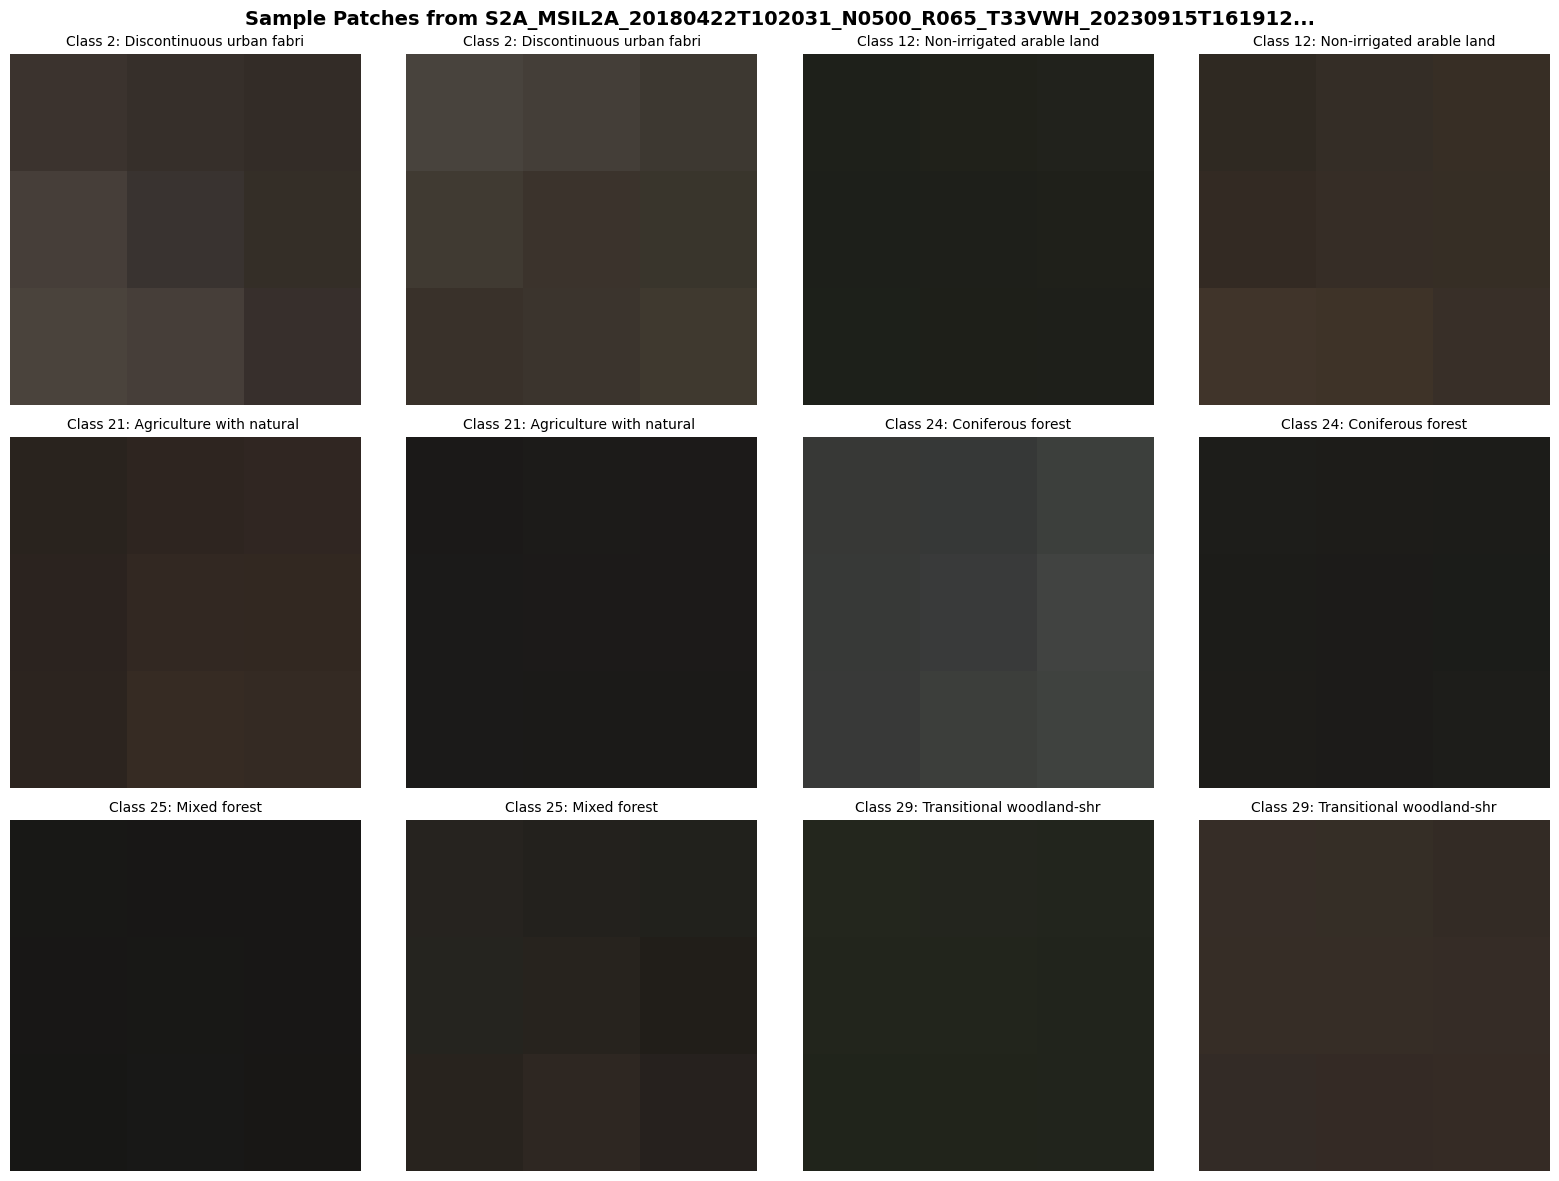

In [23]:
if successful_results:
    result = successful_results[0] # Change to visualize other results
    data = np.load(result['output_file'])
    patches = data['patches']
    labels = data['labels']
    
    print(f"Loaded {len(patches):,} patches from: {Path(result['output_file']).name}")
    print(f"Normalization: {result['metadata']['normalization']}")
    print(f"Patch value range: [{patches.min():.3f}, {patches.max():.3f}]")
    visualize_patches(patches, labels, n_samples=12, title=f"Sample Patches from {result['tile'][:]}...", is_show_plot=True)
else:
    print("No successful results to visualize.")

## Combine Multiple Tiles and Visualize class distribution

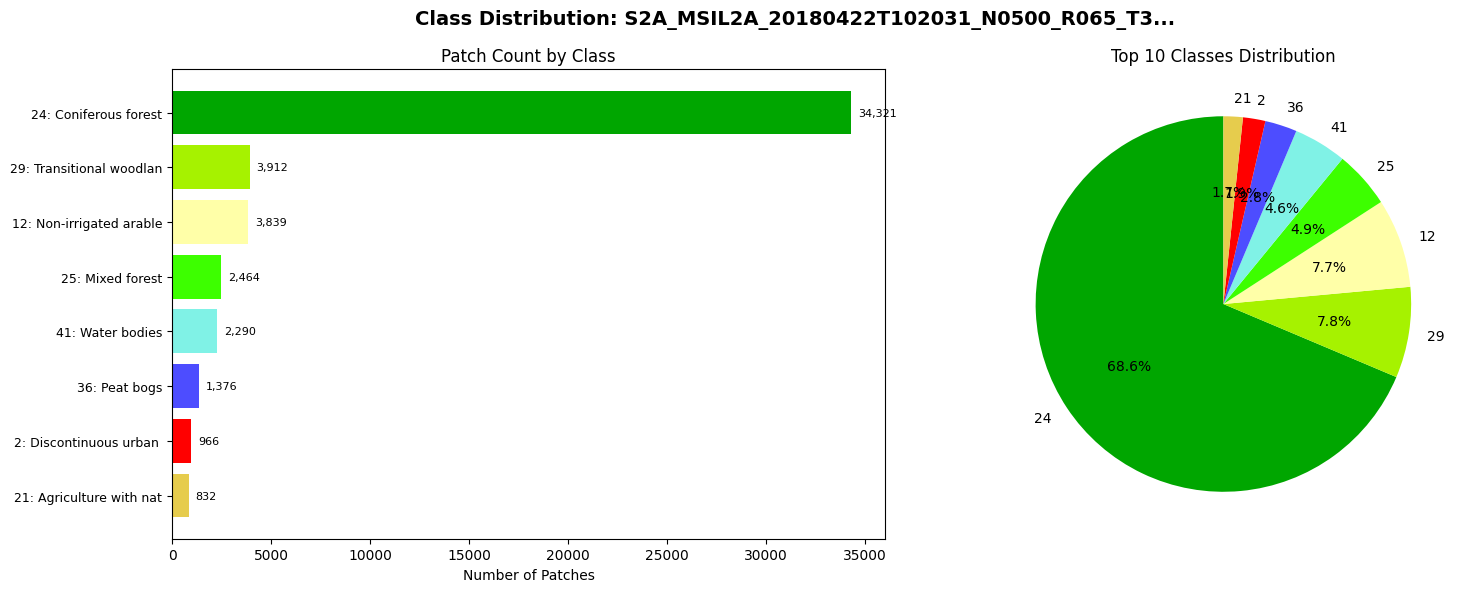


Statistics:
  Total patches: 50,000
  Unique classes: 8
  Most common: Class 24 (Coniferous forest) - 34,321 (68.6%)
  Least common: Class 21 (Agriculture with natural vegetation) - 832 (1.7%)
  Class imbalance ratio: 41.3:1


In [24]:
# Analyze first successful result
if successful_results:
    result = successful_results[0]
    data = np.load(result['output_file'])
    labels = data['labels']
    
    plot_class_distribution(labels, title=f"Class Distribution: {result['tile'][:40]}...")
else:
    print("No successful results to analyze.")

In [ ]:
# # Combine all successful results
# if len(successful_results) > 1:
#     print("Combining datasets from multiple tiles...\n")
#     combined_path = Path(TRAINING_DIR) / "combined_training_data.npz"
#     combined_patches, combined_labels = combine_datasets(all_results, combined_path)
    
#     if combined_patches is not None:
#         plot_class_distribution(combined_labels, title="Combined Dataset Class Distribution")
# elif len(successful_results) == 1:
#     print("Only one tile processed - no need to combine.")
#     print(f"Your training data is at: {successful_results[0]['output_file']}")
# else:
#     print("No successful results to combine.")



Statistics:
  Total patches: 800,000
  Unique classes: 8
  Most common: Class 24 (Coniferous forest) - 569,362 (71.2%)
  Least common: Class 21 (Agriculture with natural vegetation) - 8,019 (1.0%)
  Class imbalance ratio: 71.0:1


In [ ]:
# metadata_files = [
#     Path(r["output_file"]).with_name(
#         Path(r["output_file"]).stem.removesuffix("_data") + "_metadata.json"
#     )
#     for r in successful_results
#     if r["output_file"]
# ]

# combined_metadata_path = Path(TRAINING_DIR) / "combined_training_metadata.json"
# concatenate_metadata(metadata_files, combined_metadata_path);

## Visualization for report

✓ Figure saved to: /p/home/jusers/prokop1/jureca/project/prokop1/results/visualization_alignment.png


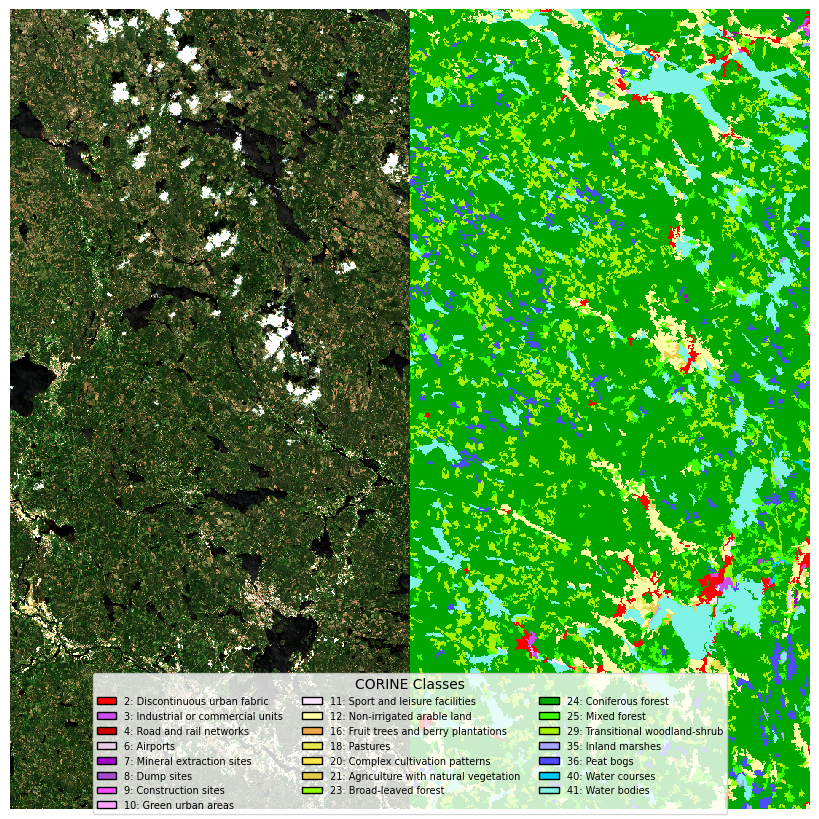

In [28]:
successful_results = [r for r in all_results if r['status'] in ['success', 'skipped']]
result = successful_results[1]
s2_path = result['s2_stacked']
corine_path = result['corine_aligned']
save_path = f"/p/home/jusers/prokop1/jureca/project/prokop1/results/visualization_alignment.png"
is_show_plot=True

with rasterio.open(s2_path) as src:
    r = src.read(3).astype(float)  # B04 (Red)
    g = src.read(2).astype(float)  # B03 (Green)
    b = src.read(1).astype(float)  # B02 (Blue)

# Create RGB composite
rgb = np.stack([r, g, b], axis=-1)
p2, p98 = np.percentile(rgb, (2, 98))
rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)

# Load CORINE data
with rasterio.open(corine_path) as src:
    corine = src.read(1)

# Create CORINE colormap
from matplotlib.colors import ListedColormap
unique_classes = np.unique(corine[(corine >= 1) & (corine <= 44)])
colors = [CORINE_COLORS.get(c, '#888888') for c in range(45)]
cmap = ListedColormap(colors)

# Create figure (subsample for display)
step = 10

# Create two subplots so images are shown side by side
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

mid = rgb.shape[1] // 2

rgb_disp = rgb[::step, :mid:step]
corine_disp = corine[::step, mid::step]

# Convert CORINE class values to RGB colors
corine_rgb = cmap(corine_disp / 44.0)[:, :, :3]

# Concatenate without any gap
combined = np.concatenate([rgb_disp, corine_rgb], axis=1)

ax.imshow(combined, interpolation='nearest')
ax.axis('off')
plt.tight_layout(pad=0)

from matplotlib.patches import Patch
legend_elements = []
for c in sorted(unique_classes):
    color = CORINE_COLORS.get(c, '#888888')
    label = f"{c}: {CORINE_CLASSES.get(c, 'Unknown')}"
    legend_elements.append(Patch(facecolor=color, edgecolor='black', label=label))
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=7,
    title="CORINE Classes",
)

if save_path:
   save_path = Path(save_path)
   save_path.parent.mkdir(parents=True, exist_ok=True)
   plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
   print(f"✓ Figure saved to: {save_path}")

if is_show_plot:
    plt.show()

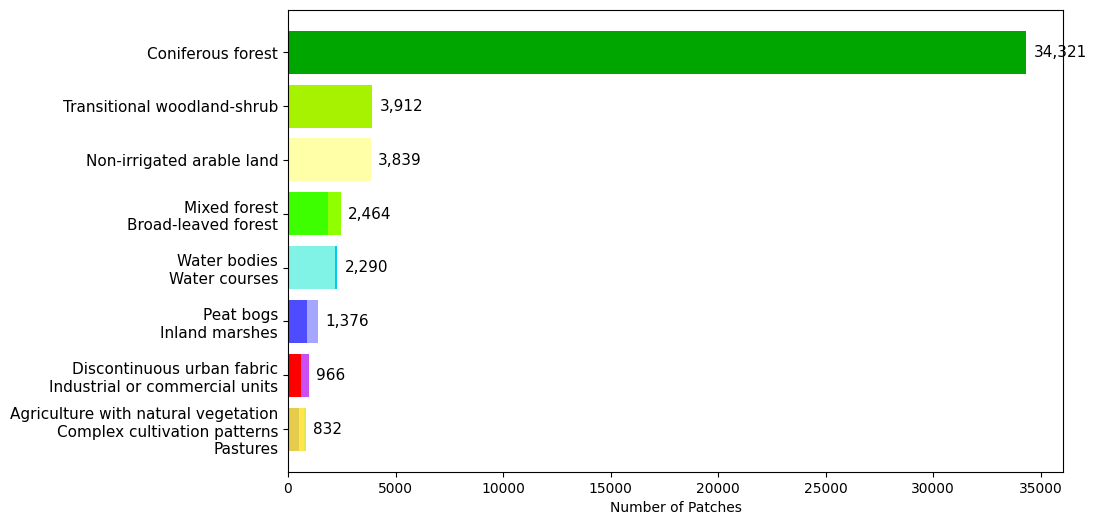

In [37]:
result = successful_results[0]
data = np.load(result['output_file'])
labels = data['labels']
save_path = Path(f"/p/home/jusers/prokop1/jureca/project/prokop1/results")
save_path.parent.mkdir(parents=True, exist_ok=True)

original_unique, original_counts = np.unique(labels, return_counts=True)

# Build combined-class composition from original classes
combined_groups = {}
for c, cnt in zip(original_unique, original_counts):
    c = int(c)
    combined_c = CORINE_REDUCE_CLASSES.get(c, c)
    combined_groups.setdefault(combined_c, []).append((c, int(cnt)))

# Sort combined classes by total count
combined_totals = {
    c: sum(cnt for _, cnt in items)
    for c, items in combined_groups.items()
}
combined_sorted = sorted(combined_groups.keys(), key=lambda c: combined_totals[c], reverse=True)

# Plot stacked horizontal bars: one bar per combined class
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(combined_sorted))
for i, combined_c in enumerate(combined_sorted):
    left = 0
    items = sorted(combined_groups[combined_c], key=lambda x: x[1], reverse=True)
    # combined_name = " and \n".join(CORINE_CLASSES.get(orig_c, f"Class {orig_c}") for orig_c, _ in items)

    for orig_c, cnt in items:
        ax.barh(
            i,
            cnt,
            left=left,
            color=CORINE_COLORS.get(orig_c, "#888888"),
            # edgecolor="white",
            linewidth=0.5,
            label=CORINE_CLASSES.get(orig_c, f"Class {orig_c}") if i == 0 else None,
        )
        left += cnt

    ax.text(left + max(combined_totals.values()) * 0.01, i, f"{left:,}", va="center", fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [
        "\n".join(
            CORINE_CLASSES.get(orig_c, f"Class {orig_c}")
            for orig_c, _ in sorted(combined_groups[c], key=lambda x: x[1], reverse=True)
        )
        for c in combined_sorted
    ],
    fontsize=11,
)
ax.set_xlabel("Number of Patches")
ax.invert_yaxis()
# ax.set_xscale('log')

# handles, labels_legend = ax.get_legend_handles_labels()
# if handles:
#     ax.legend(handles, labels_legend, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title="Original classes")

plt.savefig(save_path / "class_distribution_old_new.png", bbox_inches="tight")

# plt.tight_layout()
plt.show()